In [13]:
from utils_PI import TrajectorySegments
from utils import RAT
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import correlate2d
from scipy.ndimage import binary_dilation
from scipy.ndimage import gaussian_filter1d
from scipy.ndimage import median_filter



In [4]:
RAT_ID = 2
LIGHTING = "light"
rat = RAT(n=RAT_ID, lighting=LIGHTING, filter_speed=False) 
t = rat.T  # (s), starts at 0 
x = rat.X  # (cm) 
y = rat.Y  # (cm) 

v = rat.V  # (cm/s)
spikes_by_cell = {} 
spikes_by_cell.update(rat.grid_mod1) 
spikes_by_cell.update(rat.grid_mod2) 
spikes_by_cell.update(rat.grid_mod3)

In [21]:
def get_rate_map(spikes, x, y, t, mask, bins=50):
    # Filter trajectory by mask
    x_filt, y_filt, t_filt = x[mask], y[mask], t[mask]
    
    # Filter spikes that occurred during the mask timeframes
    # This assumes spike stamps are in the same time units as 't'
    valid_spikes = [s for s in spikes if np.interp(s, t, mask) > 0.5]
    
    # Get spike coordinates
    spike_x = np.interp(valid_spikes, t, x)
    spike_y = np.interp(valid_spikes, t, y)
    
    # Occupancy map
    occ, x_edges, y_edges = np.histogram2d(x_filt, y_filt, bins=bins)
    # Spike map
    spike_map, _, _ = np.histogram2d(spike_x, spike_y, bins=[x_edges, y_edges])
    
    # Rate map (spikes/sec)
    dt = np.median(np.diff(t))

    rate_map = spike_map / (occ * dt + 1e-9) 
    return rate_map

import numpy as np
from scipy.signal import correlate2d
from scipy.ndimage import rotate, gaussian_filter

def calculate_gridness(rate_map, smoothing_sigma=1.5):
    """
    Calculates gridness score using only numpy and scipy.
    
    Args:
        rate_map: 2D numpy array (spatial firing rates)
        smoothing_sigma: Standard deviation for Gaussian kernel
    """
    # 1. Clean up the rate map
    # Replace NaNs (from zero occupancy) with 0 and smooth
    rm = np.nan_to_num(rate_map)
    rm = gaussian_filter(rm, sigma=smoothing_sigma)
    
    # 2. Spatial Autocorrelogram (SAC)
    # We center the data by subtracting the mean of non-zero bins
    rm_centered = rm - np.mean(rm[rm > 0])
    sac = correlate2d(rm_centered, rm_centered, mode='full')
    
    # 3. Create a Ring Mask
    # We must ignore the central peak and the far edges
    y, x = np.indices(sac.shape)
    center = np.array(sac.shape) // 2
    dist = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    
    # Heuristic for ring: exclude center (inner) and noisy edges (outer)
    # Adjust these based on your bin size/arena size
    inner_radius = 3 
    outer_radius = np.min(center) * 0.9
    mask = (dist > inner_radius) & (dist < outer_radius)
    
    if not np.any(mask):
        return np.nan

    # 4. Rotational Correlation
    # We check 30, 60, 90, 120, and 150 degrees
    angles = [30, 60, 90, 120, 150]
    corrs = []
    
    # Extract values from the original SAC within the ring
    original_values = sac[mask]
    
    for angle in angles:
        # Rotate the SAC. reshape=False keeps the dimensions consistent
        rotated_sac = rotate(sac, angle, reshape=False, order=1, prefilter=False)
        rotated_values = rotated_sac[mask]
        
        # Calculate Pearson correlation
        c = np.corrcoef(original_values, rotated_values)[0, 1]
        corrs.append(c)
    
    # 5. Gridness Calculation
    # Gridness = min(correlation at 60, 120) - max(correlation at 30, 90, 150)
    grid_score = min(corrs[1], corrs[3]) - max(corrs[0], corrs[2], corrs[4])
    
    return grid_score

In [7]:

# 1. Calculate Angular Velocity (omega)
# Assuming rat.HD is head direction in radians. 
# If not available, you can derive it from the velocity vector: np.arctan2(dy, dx)
hd = rat.HD  
dt = np.median(np.diff(t))
omega = np.abs(np.gradient(hd) / dt)

# 2. Define masks for Speed and Turning
speed_mask = v > 3

# Define a threshold for "High" angular velocity (e.g., 30 degrees/s or ~0.52 rad/s)
omega_threshold = np.percentile(omega, 50) # Or a fixed value like 0.5

high_omega_mask = speed_mask & (omega > omega_threshold)
low_omega_mask = speed_mask & (omega <= omega_threshold)

In [8]:
results = {}

for cell_id, spikes in spikes_by_cell.items():
    # Rate map for Straight Runs
    rm_low = get_rate_map(spikes, x, y, t, low_omega_mask)
    # Rate map for Turns
    rm_high = get_rate_map(spikes, x, y, t, high_omega_mask)
    score_low = calculate_gridness(rm_low)
    score_high = calculate_gridness(rm_high)
    
    results[cell_id] = {'low_omega': score_low, 'high_omega': score_high}

<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_3988/4135695065.py:23: SyntaxWarning: invalid escape sequence '\o'
  axes[0, 0].set_title("Rate Map: Low $\omega$ (Straight)")
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_3988/4135695065.py:31: SyntaxWarning: invalid escape sequence '\o'
  axes[1, 0].set_title("Rate Map: High $\omega$ (Turns)")


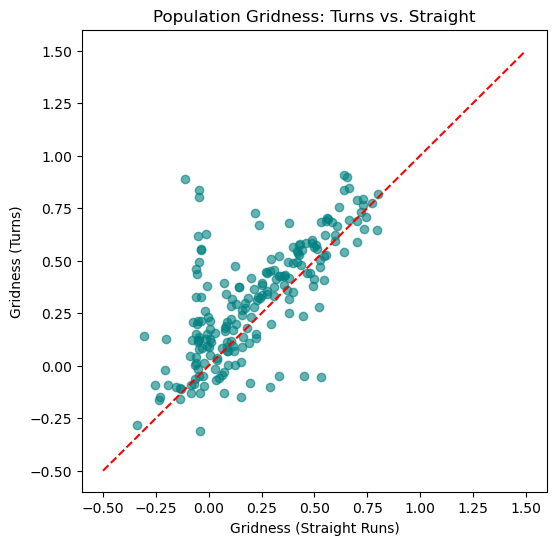

In [11]:
import matplotlib.pyplot as plt

def visualize_grid_comparison(cell_id, x, y, t, spikes, low_mask, high_mask):
    # 1. Generate Rate Maps
    rm_low = get_rate_map(spikes, x, y, t, low_mask)
    rm_high = get_rate_map(spikes, x, y, t, high_mask)
    
    # 2. Calculate SACs (for visual confirmation of gridness)
    def get_sac(rm):
        rm_reg = np.nan_to_num(rm)
        rm_reg -= np.mean(rm_reg[rm_reg > 0])
        return correlate2d(rm_reg, rm_reg, mode='full')

    sac_low = get_sac(rm_low)
    sac_high = get_sac(rm_high)

    # 3. Plotting
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    fig.suptitle(f"Cell ID: {cell_id} | Kinematic Comparison", fontsize=16)

    # Low Angular Velocity (Straight)
    im1 = axes[0, 0].imshow(rm_low, cmap='jet', origin='lower')
    axes[0, 0].set_title("Rate Map: Low $\omega$ (Straight)")
    plt.colorbar(im1, ax=axes[0, 0], label='Hz')

    im2 = axes[0, 1].imshow(sac_low, cmap='twilight', origin='lower')
    axes[0, 1].set_title(f"SAC: Grid Score = {calculate_gridness(rm_low):.2f}")

    # High Angular Velocity (Turns)
    im3 = axes[1, 0].imshow(rm_high, cmap='jet', origin='lower')
    axes[1, 0].set_title("Rate Map: High $\omega$ (Turns)")
    plt.colorbar(im3, ax=axes[1, 0], label='Hz')

    im4 = axes[1, 1].imshow(sac_high, cmap='twilight', origin='lower')
    axes[1, 1].set_title(f"SAC: Grid Score = {calculate_gridness(rm_high):.2f}")

    for ax in axes.flatten():
        ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Example usage:
# visualize_grid_comparison('cell_1', x, y, t, spikes_by_cell['cell_1'], low_omega_mask, high_omega_mask)
scores_low = [results[c]['low_omega'] for c in results]
scores_high = [results[c]['high_omega'] for c in results]

plt.figure(figsize=(6,6))
plt.scatter(scores_low, scores_high, alpha=0.6, color='teal')
plt.plot([-0.5, 1.5], [-0.5, 1.5], 'r--') # Identity line
plt.xlabel("Gridness (Straight Runs)")
plt.ylabel("Gridness (Turns)")
plt.title("Population Gridness: Turns vs. Straight")
plt.show()

<>:64: SyntaxWarning: invalid escape sequence '\o'
<>:69: SyntaxWarning: invalid escape sequence '\o'
<>:64: SyntaxWarning: invalid escape sequence '\o'
<>:69: SyntaxWarning: invalid escape sequence '\o'
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_3988/496691785.py:64: SyntaxWarning: invalid escape sequence '\o'
  axes[i, 0].set_title(f"Cell {cell_id}: Straight (Low $\omega$)")
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_3988/496691785.py:69: SyntaxWarning: invalid escape sequence '\o'
  axes[i, 1].set_title(f"Cell {cell_id}: Turns (High $\omega$)")


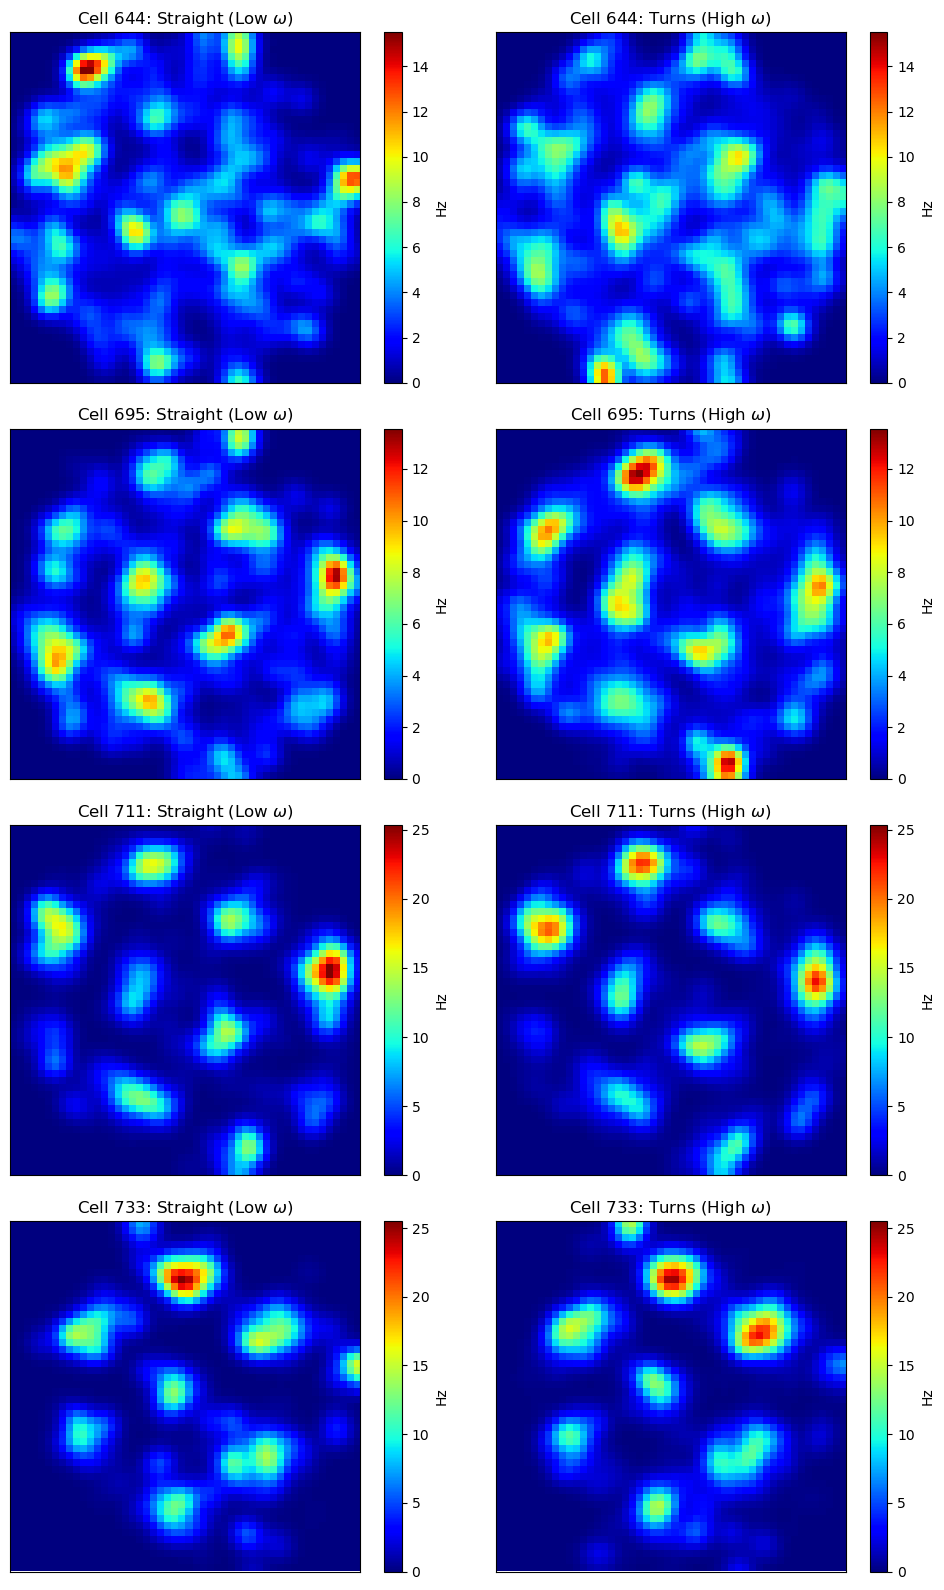

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def get_rate_map(spikes, x, y, t, mask, bins=50, smoothing=1.5):
    """Generates a smoothed spatial rate map for a given time mask."""
    # Filter trajectory and define spatial bounds
    x_f, y_f = x[mask], y[mask]
    x_range = [np.min(x), np.max(x)]
    y_range = [np.min(y), np.max(y)]
    
    # 1. Occupancy Map (time spent in each bin)
    dt = np.median(np.diff(t))
    occ, x_edges, y_edges = np.histogram2d(x_f, y_f, bins=bins, range=[x_range, y_range])
    occ_map = occ * dt
    
    # 2. Spike Map (number of spikes in each bin during the mask)
    # Find which spikes occurred during the mask
    spike_mask = np.interp(spikes, t, mask.astype(float)) > 0.5
    valid_spikes = np.array(spikes)[spike_mask]
    s_x = np.interp(valid_spikes, t, x)
    s_y = np.interp(valid_spikes, t, y)
    
    spike_counts, _, _ = np.histogram2d(s_x, s_y, bins=[x_edges, y_edges])
    
    # 3. Raw Rate Map
    rate_map = np.divide(spike_counts, occ_map, out=np.zeros_like(spike_counts), where=occ_map > 0.01)
    
    # 4. Apply Gaussian Smoothing
    if smoothing > 0:
        rate_map = gaussian_filter(rate_map, sigma=smoothing)
        
    return rate_map

# --- Kinematic Processing ---
# Calculate Angular Velocity (omega) from Head Direction (HD)
hd_unwrapped = np.unwrap(rat.HD)
dt = np.median(np.diff(t))
omega = np.abs(np.gradient(hd_unwrapped) / dt)

# Define Masks (Speed > 3cm/s)
speed_mask = v > 3
# Use a threshold (e.g., 30 deg/s converted to rad/s is ~0.52) or a median split
omega_thresh = 0.52 

low_mask = speed_mask & (omega <= omega_thresh)
high_mask = speed_mask & (omega > omega_thresh)

# --- Visualization Loop ---
cell_ids = list(spikes_by_cell.keys())[:4] # Select first 4 cells
fig, axes = plt.subplots(len(cell_ids), 2, figsize=(10, 4 * len(cell_ids)))

for i, cell_id in enumerate(cell_ids):
    spikes = spikes_by_cell[cell_id]
    
    rm_low = get_rate_map(spikes, x, y, t, low_mask)
    rm_high = get_rate_map(spikes, x, y, t, high_mask)
    
    # Find global max for consistent scaling
    vmax = max(np.max(rm_low), np.max(rm_high))
    
    # Plot Straight Runs (Low Omega)
    im1 = axes[i, 0].imshow(rm_low.T, origin='lower', cmap='jet', vmin=0, vmax=vmax)
    axes[i, 0].set_title(f"Cell {cell_id}: Straight (Low $\omega$)")
    plt.colorbar(im1, ax=axes[i, 0], label='Hz')
    
    # Plot Turns (High Omega)
    im2 = axes[i, 1].imshow(rm_high.T, origin='lower', cmap='jet', vmin=0, vmax=vmax)
    axes[i, 1].set_title(f"Cell {cell_id}: Turns (High $\omega$)")
    plt.colorbar(im2, ax=axes[i, 1], label='Hz')

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:

def clean_kinematics(omega, v, max_omega=20, max_v=100):
    """
    Cleans velocity and angular velocity data.
    max_omega: 20 rad/s is ~1145 deg/s (very fast for a rat)
    """
    # 1. Median Filter to remove 'salt and pepper' tracking noise
    # A size of 3 or 5 frames usually kills the single-frame glitches
    omega_clean = median_filter(omega, size=3)
    v_clean = median_filter(v, size=3)
    
    # 2. Hard Thresholding
    # We replace 'impossible' values with NaNs or the threshold
    outlier_mask = (omega_clean > max_omega) | (v_clean > max_v)
    
    # Let's see how many points we are losing
    print(f"Removed {np.sum(outlier_mask)} outlier points ({100*np.mean(outlier_mask):.2f}%)")
    
    omega_clean[outlier_mask] = np.nan
    v_clean[outlier_mask] = np.nan
    
    # 3. Linear Interpolation to fill the tiny gaps we just made
    nans = np.isnan(omega_clean)
    omega_clean[nans] = np.interp(t[nans], t[~nans], omega_clean[~nans])
    
    return omega_clean, v_clean

# Run the cleanup
# omega_fixed, v_fixed = clean_kinematics(omega, v)

<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:8: SyntaxWarning: invalid escape sequence '\o'
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_3988/1922067462.py:8: SyntaxWarning: invalid escape sequence '\o'
  plt.colorbar(label='Cleaned $\omega$ (rad/s)')


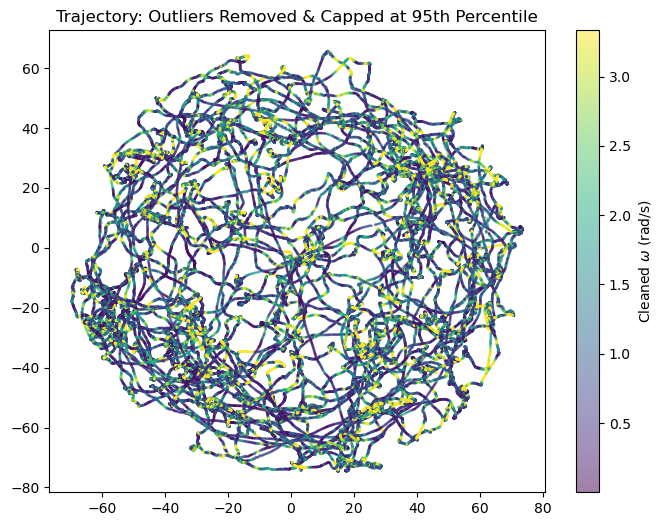

In [22]:
plt.figure(figsize=(8, 6))
# Filter out the slow points so we can focus on the movement
move_mask = v_fixed > 3 

plt.scatter(x[move_mask], y[move_mask], c=omega_fixed[move_mask], 
            cmap='viridis', s=1, alpha=0.5, vmax=np.percentile(omega_fixed, 95))

plt.colorbar(label='Cleaned $\omega$ (rad/s)')
plt.title("Trajectory: Outliers Removed & Capped at 95th Percentile")
plt.show()

In [15]:
from matplotlib.collections import LineCollection

def plot_trajectory_omega(x, y, omega, mask):
    # Filter data by movement mask
    xf, yf, wf = x[mask], y[mask], omega[mask]
    
    # Create segments for LineCollection (required for multi-colored lines)
    points = np.array([xf, yf]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create the line collection
    # Normalize color based on the 95th percentile to keep outliers from washing out the plot
    norm = plt.Normalize(0, np.percentile(wf, 95))
    lc = LineCollection(segments, cmap='winter', norm=norm, alpha=0.8)
    
    # Set the values used for colormapping
    lc.set_array(wf)
    lc.set_linewidth(1.5)
    
    line = ax.add_collection(lc)
    fig.colorbar(line, ax=ax, label='Angular Velocity (rad/s)')
    
    ax.set_xlim(x.min()-2, x.max()+2)
    ax.set_ylim(y.min()-2, y.max()+2)
    ax.set_title("Trajectory Colored by Movement Angular Velocity ($\omega$)", fontsize=14)
    ax.set_aspect('equal')
    ax.set_xlabel("X (cm)")
    ax.set_ylabel("Y (cm)")
    
    plt.show()


<>:27: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\o'
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_4458/3415940114.py:27: SyntaxWarning: invalid escape sequence '\o'
  ax.set_title("Trajectory Colored by Movement Angular Velocity ($\omega$)", fontsize=14)


<>:52: SyntaxWarning: invalid escape sequence '\o'
<>:52: SyntaxWarning: invalid escape sequence '\o'
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_3988/2676283038.py:52: SyntaxWarning: invalid escape sequence '\o'
  ax.set_title("Trajectory Colored by Movement Angular Velocity ($\omega$)", fontsize=14)


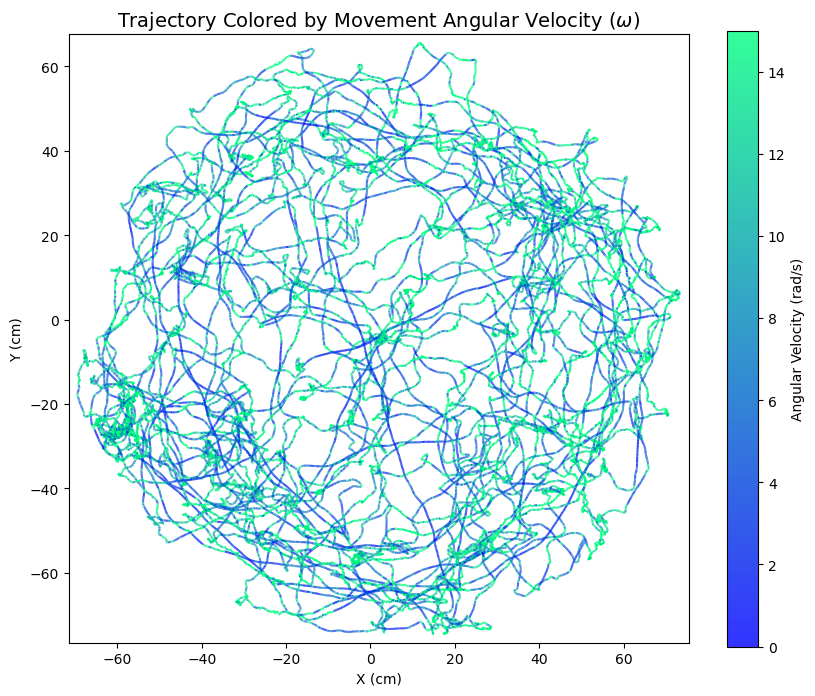

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

# 1. Calculate change in position
dx = np.gradient(x)
dy = np.gradient(y)

# 2. Calculate movement angle (phi) and UNWRAP it
# This prevents 360-degree jumps from looking like infinite velocity
move_angle = np.unwrap(np.arctan2(dy, dx))

# 3. Calculate Angular Velocity (omega)
dt = np.median(np.diff(t))
omega_raw = np.abs(np.gradient(move_angle) / dt)

# 4. Cleanup: Apply a median filter to catch tracking "glitches" 
# and cap at a reasonable biological limit (e.g., 15 rad/s)
omega_clean = median_filter(omega_raw, size=3)
omega_clean = np.clip(omega_clean, 0, 15) 

# 5. Mask for movement only (Speed > 3 cm/s)
move_mask = v > 3



plot_trajectory_omega(x, y, omega_clean, move_mask)

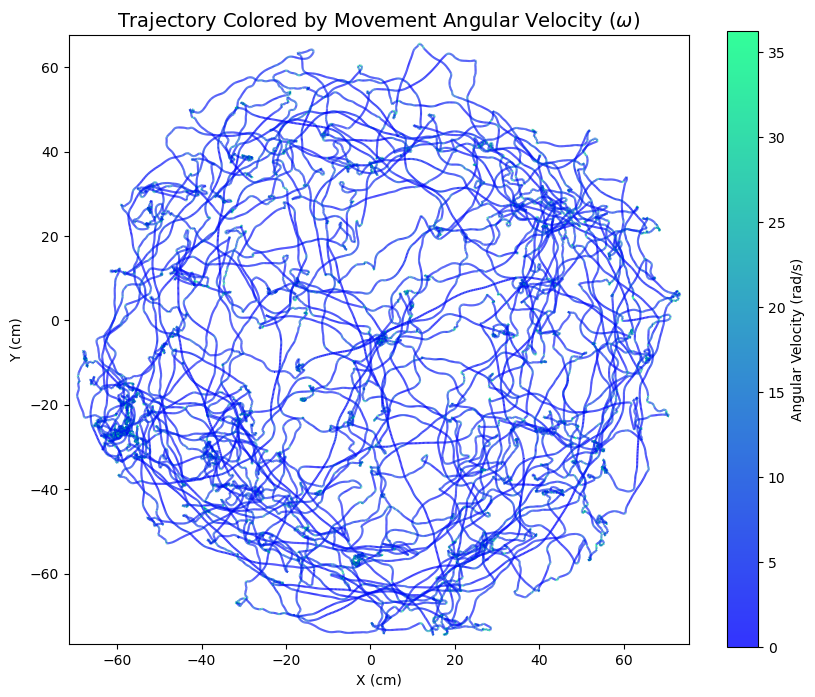

In [27]:
from scipy.ndimage import gaussian_filter1d

# 1. Smooth the raw coordinates
# 'sigma' controls the smoothing. Start with 2-5 frames (approx. 40-100ms)
sigma_smoothing = 2
x_smooth = gaussian_filter1d(x, sigma=sigma_smoothing)
y_smooth = gaussian_filter1d(y, sigma=sigma_smoothing)

# 2. Recalculate dx, dy from smoothed data
dx_s = np.gradient(x_smooth)
dy_s = np.gradient(y_smooth)

# 3. Recalculate angle and unwrap
move_angle_s = np.unwrap(np.arctan2(dy_s, dx_s))

# 4. Calculate omega from the smoothed angle
dt = np.median(np.diff(t))
omega_fixed = np.abs(np.gradient(move_angle_s) / dt)

# Apply a small median filter to omega itself just to be safe
omega_fixed = median_filter(omega_fixed, size=3)
plot_trajectory_omega(x_smooth, y_smooth, omega_fixed, move_mask)

In [35]:
omega_threshold = np.percentile(omega_fixed, 80) # Or a fixed value like 0.5

high_omega_mask = speed_mask & (omega_fixed > omega_threshold)
low_omega_mask = speed_mask & (omega_fixed <= omega_threshold)

In [32]:
results = {}

for cell_id, spikes in spikes_by_cell.items():
    # Rate map for Straight Runs
    rm_low = get_rate_map(spikes, x, y, t, low_omega_mask)
    # Rate map for Turns
    rm_high = get_rate_map(spikes, x, y, t, high_omega_mask)
    score_low = calculate_gridness(rm_low)
    score_high = calculate_gridness(rm_high)
    
    results[cell_id] = {'low_omega': score_low, 'high_omega': score_high}

<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:31: SyntaxWarning: invalid escape sequence '\o'
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_3988/4135695065.py:23: SyntaxWarning: invalid escape sequence '\o'
  axes[0, 0].set_title("Rate Map: Low $\omega$ (Straight)")
/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_3988/4135695065.py:31: SyntaxWarning: invalid escape sequence '\o'
  axes[1, 0].set_title("Rate Map: High $\omega$ (Turns)")


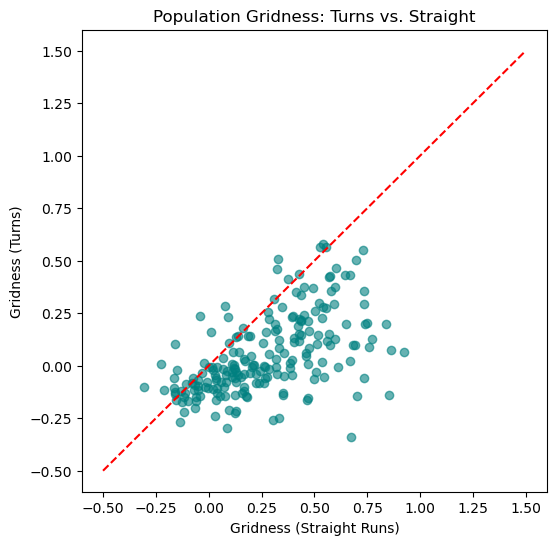

In [33]:
import matplotlib.pyplot as plt

def visualize_grid_comparison(cell_id, x, y, t, spikes, low_mask, high_mask):
    # 1. Generate Rate Maps
    rm_low = get_rate_map(spikes, x, y, t, low_mask)
    rm_high = get_rate_map(spikes, x, y, t, high_mask)
    
    # 2. Calculate SACs (for visual confirmation of gridness)
    def get_sac(rm):
        rm_reg = np.nan_to_num(rm)
        rm_reg -= np.mean(rm_reg[rm_reg > 0])
        return correlate2d(rm_reg, rm_reg, mode='full')

    sac_low = get_sac(rm_low)
    sac_high = get_sac(rm_high)

    # 3. Plotting
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    fig.suptitle(f"Cell ID: {cell_id} | Kinematic Comparison", fontsize=16)

    # Low Angular Velocity (Straight)
    im1 = axes[0, 0].imshow(rm_low, cmap='jet', origin='lower')
    axes[0, 0].set_title("Rate Map: Low $\omega$ (Straight)")
    plt.colorbar(im1, ax=axes[0, 0], label='Hz')

    im2 = axes[0, 1].imshow(sac_low, cmap='twilight', origin='lower')
    axes[0, 1].set_title(f"SAC: Grid Score = {calculate_gridness(rm_low):.2f}")

    # High Angular Velocity (Turns)
    im3 = axes[1, 0].imshow(rm_high, cmap='jet', origin='lower')
    axes[1, 0].set_title("Rate Map: High $\omega$ (Turns)")
    plt.colorbar(im3, ax=axes[1, 0], label='Hz')

    im4 = axes[1, 1].imshow(sac_high, cmap='twilight', origin='lower')
    axes[1, 1].set_title(f"SAC: Grid Score = {calculate_gridness(rm_high):.2f}")

    for ax in axes.flatten():
        ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Example usage:
# visualize_grid_comparison('cell_1', x, y, t, spikes_by_cell['cell_1'], low_omega_mask, high_omega_mask)
scores_low = [results[c]['low_omega'] for c in results]
scores_high = [results[c]['high_omega'] for c in results]

plt.figure(figsize=(6,6))
plt.scatter(scores_low, scores_high, alpha=0.6, color='teal')
plt.plot([-0.5, 1.5], [-0.5, 1.5], 'r--') # Identity line
plt.xlabel("Gridness (Straight Runs)")
plt.ylabel("Gridness (Turns)")
plt.title("Population Gridness: Turns vs. Straight")
plt.show()

In [4]:
def get_subsampled_mask(full_mask, target_duration_points):
    """
    Randomly selects indices from a mask until a target number of points is reached.
    """
    # Get all indices where the rat was moving straight
    true_indices = np.where(full_mask)[0]
    
    if len(true_indices) <= target_duration_points:
        return full_mask # Can't subsample further
        
    # Randomly pick indices to keep
    chosen_indices = np.random.choice(true_indices, size=target_duration_points, replace=False)
    
    # Create a new boolean mask
    sub_mask = np.zeros_like(full_mask, dtype=bool)
    sub_mask[chosen_indices] = True
    return sub_mask


# omega_threshold = np.percentile(omega_fixed, 80) # Or a fixed value like 0.5

# high_omega_mask = speed_mask & (omega_fixed > omega_threshold)
# low_omega_mask = speed_mask & (omega_fixed <= omega_threshold)
# # --- Execution ---
# # Count how many samples are in your "Turn" data
# n_turn_samples = np.sum(high_omega_mask)
# n_straight_samples = np.sum(low_omega_mask)

# print(f"Original Straight samples: {n_straight_samples}")
# print(f"Target (Turn) samples: {n_turn_samples}")

# # Create the balanced mask
# low_mask_subsampled = get_subsampled_mask(low_omega_mask, n_turn_samples)

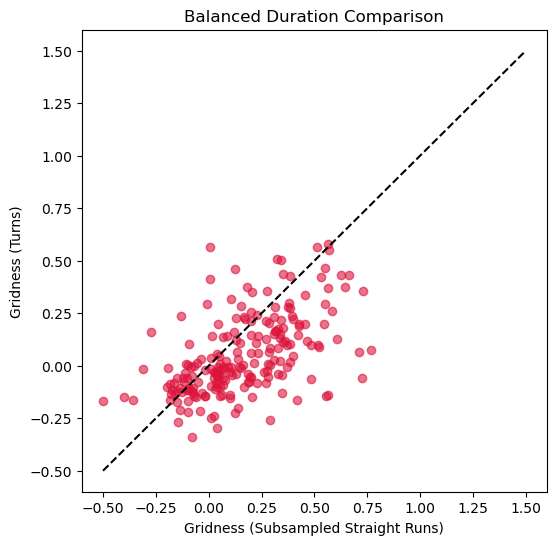

In [39]:
balanced_results = {}

for cell_id, spikes in spikes_by_cell.items():
    # Rate Map for Turns
    rm_high = get_rate_map(spikes, x, y, t, high_omega_mask)
    # Rate Map for Subsampled Straight (Balanced Duration)
    rm_low_bal = get_rate_map(spikes, x, y, t, low_mask_subsampled)
    
    # Gridness
    score_high = calculate_gridness(rm_high)
    score_low_bal = calculate_gridness(rm_low_bal)
    
    balanced_results[cell_id] = {'straight_bal': score_low_bal, 'turns': score_high}

# Visualization: Scatter plot of Balanced Straight vs Turns
scores_low_bal = [balanced_results[c]['straight_bal'] for c in balanced_results]
scores_high = [balanced_results[c]['turns'] for c in balanced_results]

plt.figure(figsize=(6,6))
plt.scatter(scores_low_bal, scores_high, alpha=0.6, color='crimson')
plt.plot([-0.5, 1.5], [-0.5, 1.5], 'k--')
plt.xlabel("Gridness (Subsampled Straight Runs)")
plt.ylabel("Gridness (Turns)")
plt.title("Balanced Duration Comparison")
plt.show()

In [25]:
RAT_ID = 2
LIGHTING = "light"
def gridness_turn(RAT_ID , LIGHTING):
    rat = RAT(n=RAT_ID, lighting=LIGHTING, filter_speed=False) 
    t = rat.T  # (s), starts at 0 
    x = rat.X  # (cm) 
    y = rat.Y  # (cm) 

    v = rat.V  # (cm/s)
    spikes_by_cell = {} 
    spikes_by_cell.update(rat.grid_mod1) 
    spikes_by_cell.update(rat.grid_mod2) 
    spikes_by_cell.update(rat.grid_mod3)
    sigma_smoothing = 2
    x_smooth = gaussian_filter1d(x, sigma=sigma_smoothing)
    y_smooth = gaussian_filter1d(y, sigma=sigma_smoothing)

    # 2. Recalculate dx, dy from smoothed data
    dx_s = np.gradient(x_smooth)
    dy_s = np.gradient(y_smooth)

    # 3. Recalculate angle and unwrap
    move_angle_s = np.unwrap(np.arctan2(dy_s, dx_s))

    # 4. Calculate omega from the smoothed angle
    dt = np.median(np.diff(t))
    omega_fixed = np.abs(np.gradient(move_angle_s) / dt)

    # Apply a small median filter to omega itself just to be safe
    omega_fixed = median_filter(omega_fixed, size=3)
    move_mask = v > 3

    # plot_trajectory_omega(x_smooth, y_smooth, omega_fixed, move_mask)
    omega_threshold = np.percentile(omega_fixed, 80) # Or a fixed value like 0.5

    high_omega_mask = move_mask & (omega_fixed > omega_threshold)
    low_omega_mask = move_mask & (omega_fixed <= omega_threshold)

    n_turn_samples = np.sum(high_omega_mask)
    n_straight_samples = np.sum(low_omega_mask)

    print(f"Original Straight samples: {n_straight_samples}")
    print(f"Target (Turn) samples: {n_turn_samples}")

    # Create the balanced mask
    low_mask_subsampled = get_subsampled_mask(low_omega_mask, n_turn_samples)

    balanced_results = {}

    for cell_id, spikes in spikes_by_cell.items():
        # Rate Map for Turns
        rm_high = get_rate_map(spikes, x, y, t, high_omega_mask)
        # Rate Map for Subsampled Straight (Balanced Duration)
        rm_low_bal = get_rate_map(spikes, x, y, t, low_mask_subsampled)
        
        # Gridness
        score_high = calculate_gridness(rm_high)
        score_low_bal = calculate_gridness(rm_low_bal)
        
        balanced_results[cell_id] = {'straight_bal': score_low_bal, 'turns': score_high}

    # Visualization: Scatter plot of Balanced Straight vs Turns
    scores_low_bal = [balanced_results[c]['straight_bal'] for c in balanced_results]
    scores_high = [balanced_results[c]['turns'] for c in balanced_results]
    return scores_low_bal, scores_high
    plt.figure(figsize=(6,6))
    plt.scatter(scores_low_bal, scores_high, alpha=0.6, color='crimson')
    plt.plot([-0.5, 1.5], [-0.5, 1.5], 'k--')
    plt.xlabel("Gridness (Subsampled Straight Runs)")
    plt.ylabel("Gridness (Turns)")
    plt.title("Balanced Duration Comparison")
    plt.show()
            

        

In [26]:
rats = [1, 2, 3, 4, 5]
conditions = ['light', 'dark']

all_results = []

for rid in rats:
    for cond in conditions:
        print(f"Processing Rat {rid} - Condition: {cond}...")
        try:
            low_bal, high = gridness_turn(rid, cond)
            all_results.append({
                'rat': rid,
                'cond': cond,
                'low_bal': low_bal,
                'high': high
            })
        except Exception as e:
            print(f"Error processing Rat {rid} {cond}: {e}")

Processing Rat 1 - Condition: light...
Original Straight samples: 245372
Target (Turn) samples: 21474
Processing Rat 1 - Condition: dark...
Original Straight samples: 289647
Target (Turn) samples: 39466
Processing Rat 2 - Condition: light...
Original Straight samples: 120427
Target (Turn) samples: 9283
Processing Rat 2 - Condition: dark...
Original Straight samples: 195258
Target (Turn) samples: 13791
Processing Rat 3 - Condition: light...
Original Straight samples: 152703
Target (Turn) samples: 14453
Processing Rat 3 - Condition: dark...
Original Straight samples: 260611
Target (Turn) samples: 32493
Processing Rat 4 - Condition: light...
Original Straight samples: 203131
Target (Turn) samples: 22838
Processing Rat 4 - Condition: dark...
Original Straight samples: 230313
Target (Turn) samples: 34896
Processing Rat 5 - Condition: light...
Original Straight samples: 97613
Target (Turn) samples: 7806
Processing Rat 5 - Condition: dark...
Original Straight samples: 218073
Target (Turn) sam

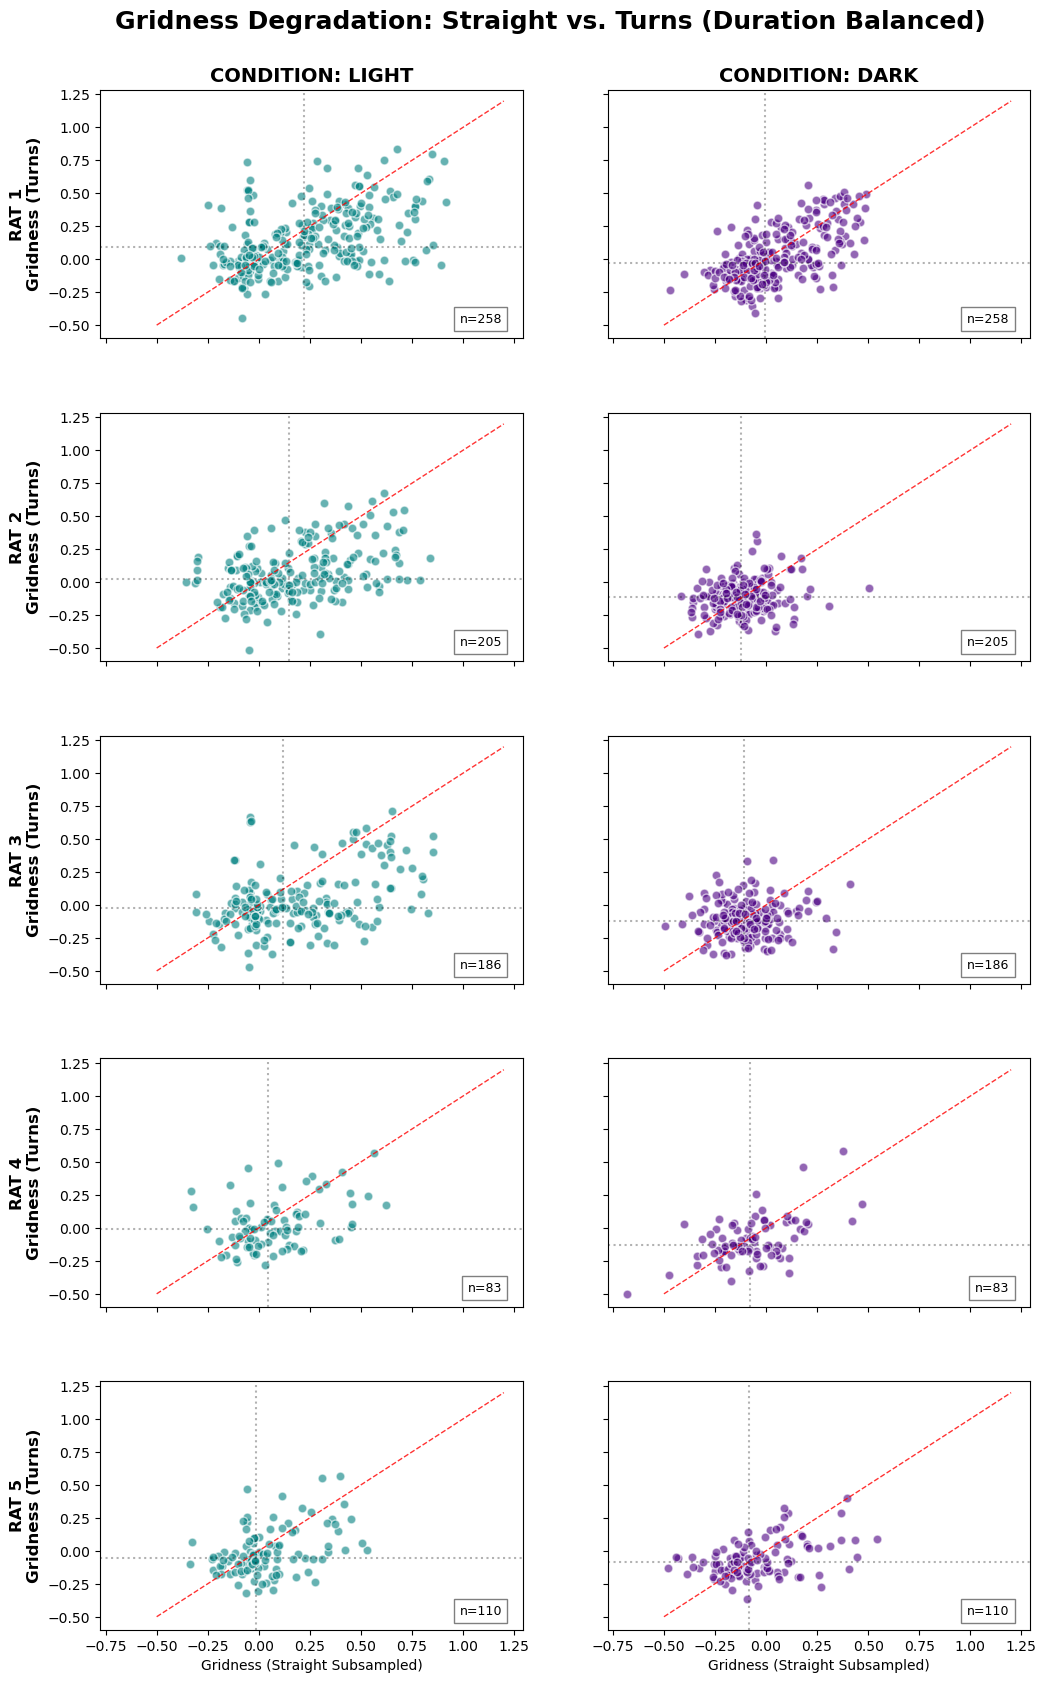

In [31]:
import matplotlib.pyplot as plt
all_results_lst = all_results
# 1. Setup the 5x2 grid
fig, axes = plt.subplots(5, 2, figsize=(12, 20), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# Define conditions for column indexing
cond_map = {'light': 0, 'dark': 1}
colors = {'light': 'teal', 'dark': 'indigo'}

for res in all_results_lst:
    rid = res['rat']
    cond = res['cond']
    low_bal = res['low_bal']
    high = res['high']
    
    # Identify the correct subplot (Rat ID is 1-indexed, so we subtract 1)
    row = rid - 1
    col = cond_map[cond]
    ax = axes[row, col]
    
    # 2. Scatter plot for this specific Rat and Condition
    ax.scatter(low_bal, high, alpha=0.6, color=colors[cond], edgecolor='w', s=40)
    
    # 3. Add Identity line (Straight == Turns)
    ax.plot([-0.5, 1.2], [-0.5, 1.2], 'r--', alpha=0.8, linewidth=1)
    
    # 4. Statistical markers (Medians)
    med_low = np.nanmedian(low_bal)
    med_high = np.nanmedian(high)
    ax.axvline(med_low, color='black', linestyle=':', alpha=0.3)
    ax.axhline(med_high, color='black', linestyle=':', alpha=0.3)
    
    # Formatting
    if row == 0:
        ax.set_title(f"CONDITION: {cond.upper()}", fontsize=14, fontweight='bold')
    if col == 0:
        ax.set_ylabel(f"RAT {rid}\nGridness (Turns)", fontsize=12, fontweight='bold')
    if row == 4:
        ax.set_xlabel("Gridness (Straight Subsampled)", fontsize=10)

    # Add a small text box with the count of cells
    ax.text(0.95, 0.05, f"n={len(low_bal)}", transform=ax.transAxes, 
            ha='right', va='bottom', fontsize=9, bbox=dict(facecolor='white', alpha=0.5))

plt.suptitle("Gridness Degradation: Straight vs. Turns (Duration Balanced)", 
             fontsize=18, y=0.92, fontweight='bold')

plt.show()

In [32]:
import pandas as pd
from scipy import stats

summary_stats = []

for res in all_results_lst:
    s_scores = np.array(res['low_bal'])
    t_scores = np.array(res['high'])
    
    # 1. Count points below the line
    n_below = np.sum(s_scores > t_scores)
    pct_below = (n_below / len(s_scores)) * 100
    
    # 2. Mean Difference (The Drop)
    delta = s_scores - t_scores
    avg_drop = np.nanmean(delta)
    
    # 3. Wilcoxon Signed-Rank Test (Is the shift significant?)
    # We use Wilcoxon because gridness scores aren't always normally distributed
    stat, p_val = stats.wilcoxon(s_scores, t_scores)
    
    summary_stats.append({
        'Rat': res['rat'],
        'Cond': res['cond'],
        'Pct_Below': pct_below,
        'Mean_Drop': avg_drop,
        'P_Value': p_val
    })

# Convert to a readable Table
df_summary = pd.DataFrame(summary_stats)
print(df_summary)

   Rat   Cond  Pct_Below  Mean_Drop       P_Value
0    1  light  64.728682   0.088381  1.593589e-07
1    1   dark  55.038760   0.026344  1.936872e-02
2    2  light  64.878049   0.109686  1.618682e-08
3    2   dark  47.317073  -0.002716  4.541786e-01
4    3  light  73.118280   0.154935  2.089651e-12
5    3   dark  54.301075   0.016444  1.676386e-01
6    4  light  60.240964   0.053001  8.919681e-03
7    4   dark  51.807229   0.021708  3.070033e-01
8    5  light  65.454545   0.051587  8.871409e-03
9    5   dark  52.727273   0.022339  4.284766e-01


/var/folders/xj/wkkjdrdj4m34d65kdvfzm6zw0000gn/T/ipykernel_4458/951828357.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Gridness Drop', data=pd.DataFrame(plot_data), palette='Set2')


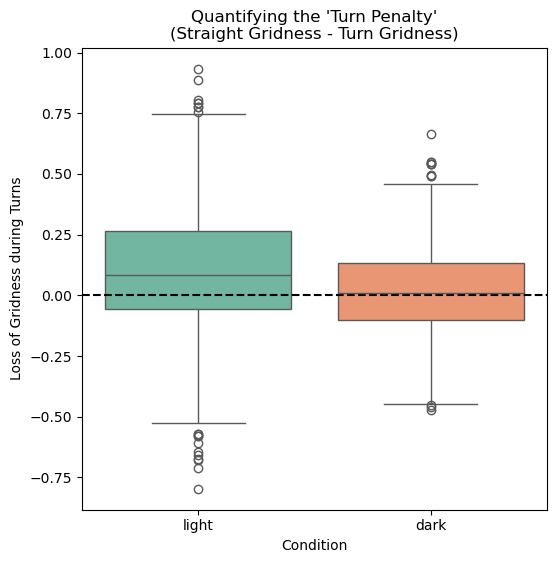

In [33]:
import seaborn as sns

# Flatten the deltas for a boxplot
plot_data = []
for res in all_results_lst:
    deltas = np.array(res['low_bal']) - np.array(res['high'])
    for d in deltas:
        plot_data.append({'Condition': res['cond'], 'Gridness Drop': d})

plt.figure(figsize=(6, 6))
sns.boxplot(x='Condition', y='Gridness Drop', data=pd.DataFrame(plot_data), palette='Set2')
plt.axhline(0, color='black', linestyle='--')
plt.title("Quantifying the 'Turn Penalty'\n(Straight Gridness - Turn Gridness)")
plt.ylabel("Loss of Gridness during Turns")
plt.show()